In [2]:
import pandas as pd
import numpy as np
from metric.similarity import WeightedUserSimilarity
import matplotlib.pyplot as plt

In [3]:
TRAIN_PATH = '../data/train.csv'

train_data = pd.read_csv(TRAIN_PATH)

train_data

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0
...,...,...,...
390346,77801,185970,5.0
390347,77801,185971,5.0
390348,77802,44671,10.0
390349,77803,154450,10.0


     n_appearances   count
0                1  120474
1                2   23790
2                3    9127
3                4    4778
4                5    2969
..             ...     ...
175            157       1
176            158       1
177            161       1
178            164       1
179            707       1

[180 rows x 2 columns]


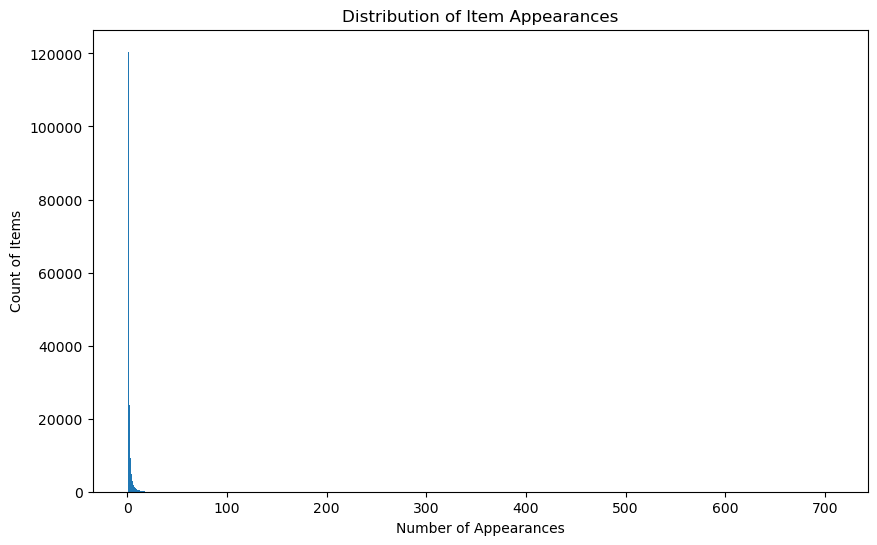

In [4]:
# Count the times each item appears in the dataset
item_counts = train_data['item'].value_counts()

n_appearances = item_counts.value_counts()

n_appearances = n_appearances.rename_axis('n_appearances').reset_index(name='count')

print(n_appearances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(n_appearances['n_appearances'], n_appearances['count'])
ax.set_xlabel('Number of Appearances')
ax.set_ylabel('Count of Items')
ax.set_title('Distribution of Item Appearances')
plt.show()

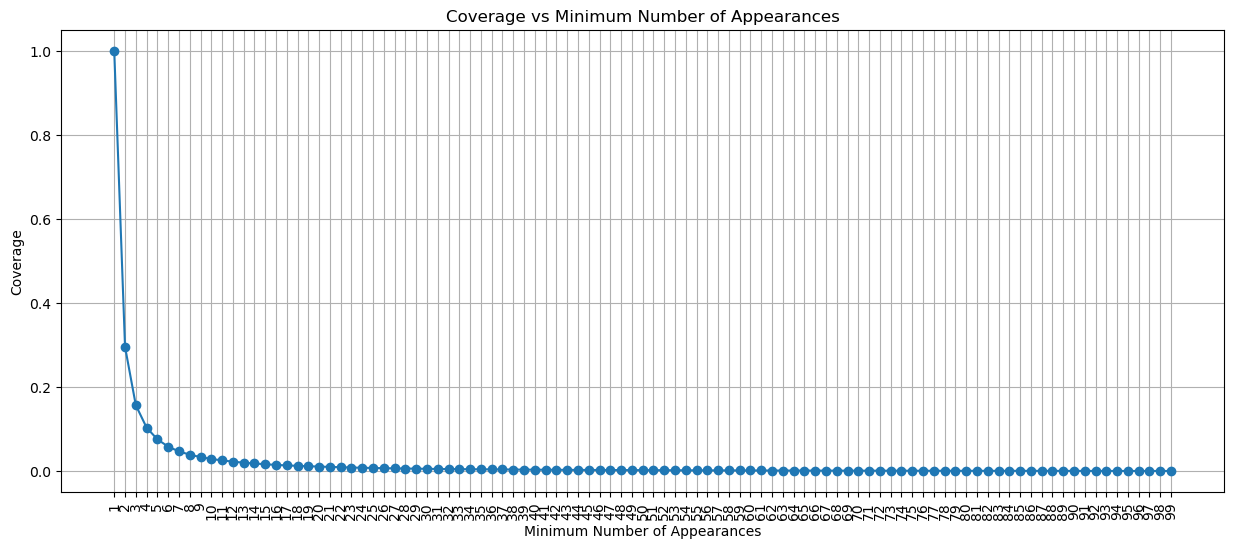

In [5]:
# I want to see the coverage if i only recommend items that appear at least n times
# I will calculate the coverage for different values of n and plot it

total_items = len(item_counts)
coverage = []

for n in range(1, 100):
    items_to_recommend = item_counts[item_counts >= n].index
    coverage.append(len(items_to_recommend) / total_items)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(range(1, 100), coverage, marker='o')
ax.set_xlabel('Minimum Number of Appearances')
ax.set_ylabel('Coverage')
ax.set_title('Coverage vs Minimum Number of Appearances')
plt.xticks(range(1, 100), rotation=90)
plt.grid()
plt.show()

In [ ]:
from model.PMF import MatrixFactorization
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(train_data, test_size=0.2, random_state=42)

mf = MatrixFactorization(n_factors=10, n_epochs=80, lr=0.1, reg=0.5, verbose=True)
mf = mf.fit(train_data)

predictions = mf.predict_df(test_data)

predictions

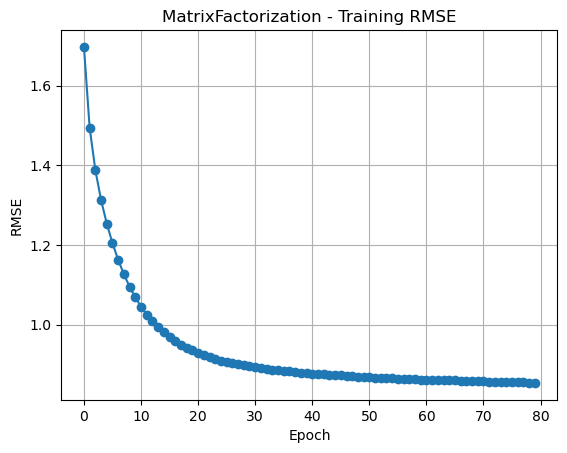

In [6]:
mf.plot_training()

Mean Absolute Error: 1.3368


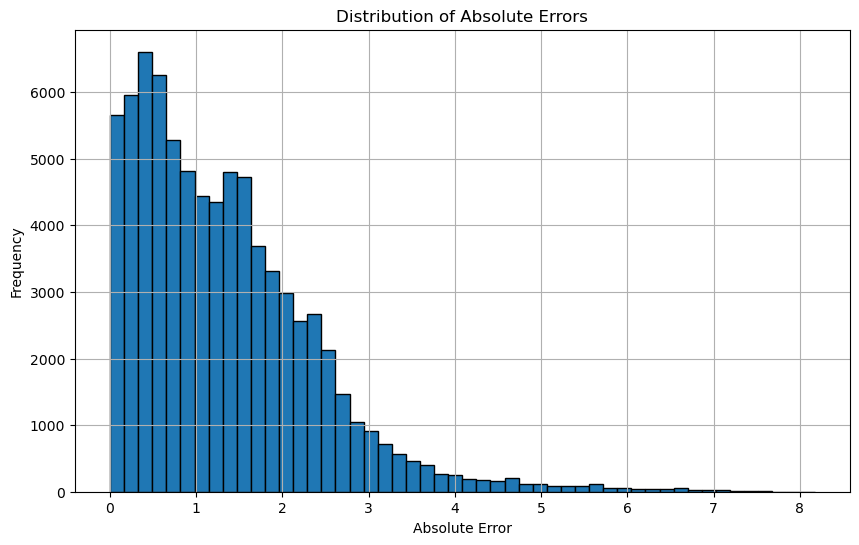

In [7]:
errors = np.abs(predictions['rating'] - predictions['prediction'])

print(f'Mean Absolute Error: {errors.mean():.4f}')
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=50, edgecolor='k')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.grid()

In [ ]:
mf_10 = MatrixFactorization(n_factors=10, n_epochs=80, lr=0.1, reg=0.5, verbose=False)

mf_20 = MatrixFactorization(n_factors=20, n_epochs=80, lr=0.1, reg=0.1, verbose=False)

mf_30 = MatrixFactorization(n_factors=30, n_epochs=80, lr=0.1, reg=0.1, verbose=False)

mf_40 = MatrixFactorization(n_factors=40, n_epochs=100, lr=0.05, reg=0.5, verbose=False)

mf_50 = MatrixFactorization(n_factors=50, n_epochs=100, lr=0.05, reg=0.1, verbose=False)

models = [mf_10, mf_20, mf_30, mf_40, mf_50]

for model in models:
    model.fit(train_data)
    predictions = model.predict_df(test_data)
    errors = np.abs(predictions['rating'] - predictions['prediction'])
    print(f'Mean Absolute Error for {model.n_factors} factors: {errors.mean():.4f}')

Mean Absolute Error for 10 factors: 1.3368
Mean Absolute Error for 20 factors: 1.3335
Mean Absolute Error for 30 factors: 1.3258
Mean Absolute Error for 40 factors: 1119.1639
Mean Absolute Error for 50 factors: 500.8417


Mean Absolute Error for Ensemble: 4.6012


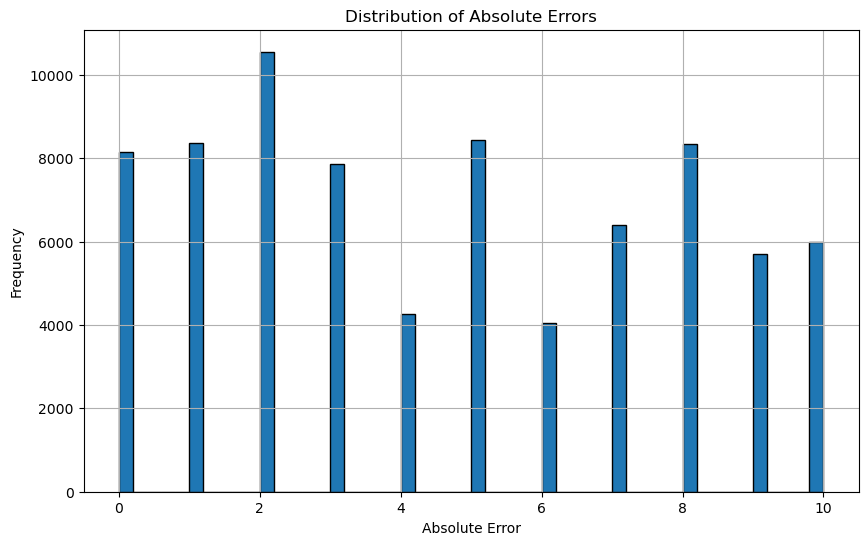

In [9]:
from ensemble.ensemble import RatingEnsemble

ensemble = RatingEnsemble(models=models, weights=[0.2, 0.2, 0.2, 0.2, 0.2], strategy='mean', clip_range=(0, 10))

ensemble_predictions = ensemble.predict_df(test_data, round_predictions=True)

ensemble_errors = np.abs(ensemble_predictions['rating'] - ensemble_predictions['prediction'])
print(f'Mean Absolute Error for Ensemble: {ensemble_errors.mean():.4f}')

plt.figure(figsize=(10, 6))
plt.hist(ensemble_errors, bins=50, edgecolor='k')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors')
plt.grid()
plt.show()

In [10]:
from utils.predict import Predictor

predictor = Predictor(test_path='../data/test.csv', save_path='../data/solution_v2.csv', round_predictions=True)
solution_df = predictor.predict(ensemble)
solution_df.head()

,ID,rating
0,0,10.0
1,1,10.0
2,2,0.0
3,3,10.0
4,4,9.0


In [12]:
for model in models:
    model.save(f'../models/pmf/pmf_{model.n_factors}_factors.joblib')

In [7]:
import os
from model.PMF import MatrixFactorization

model_files = [f for f in os.listdir('../models/pmf') if f.endswith('.joblib')]

models = []

for model_file in model_files:
    model_path = os.path.join('../models/pmf', model_file)
    loaded_model = MatrixFactorization.load(model_path)
    print(f'Loaded model from {model_file} with {loaded_model.n_factors} factors')
    models.append(loaded_model)

models = models[:3]

Loaded model from pmf_10_factors.joblib with 10 factors
Loaded model from pmf_20_factors.joblib with 20 factors
Loaded model from pmf_30_factors.joblib with 30 factors
Loaded model from pmf_40_factors.joblib with 40 factors
Loaded model from pmf_50_factors.joblib with 50 factors


In [ ]:
from model.PMF import PMFRegressor

pmf_regressor_rf = PMFRegressor(pmf=models[2], model="randomforest", clip_range=(0, 10))
pmf_regressor_rf.fit(train_data)
regressor_predictions = pmf_regressor_rf.predict_df(test_data, round_predictions=True)

regressor_errors = np.abs(regressor_predictions['rating'] - regressor_predictions['prediction'])
print(f'Mean Absolute Error for PMF Regressor: {regressor_errors.mean():.4f}')
plt.figure(figsize=(10, 6))
plt.hist(regressor_errors, bins=50, edgecolor='k')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors for PMF Regressor')
plt.grid()
plt.show()

In [10]:
pmf_regressor_m20 = PMFRegressor(pmf=models[1], model="randomforest", clip_range=(0, 10))
pmf_regressor_m20.fit(train_data)

print("RandomForest Trained")

pmf_regressor_m30_svr = PMFRegressor(pmf=models[2], model="svr", clip_range=(0, 10))
pmf_regressor_m30_svr.fit(train_data)

print("SVR Trained")

pmf_regressor_m30_lasso = PMFRegressor(pmf=models[2], model="lasso", clip_range=(0, 10))
pmf_regressor_m30_lasso.fit(train_data)

print("Lasso Trained")

# Check the errors for each regressor
regressors = {
    "Random Forest (mf_20)": pmf_regressor_m20,
    "SVR (mf_30)": pmf_regressor_m30_svr,
    "Lasso (mf_30)": pmf_regressor_m30_lasso
}

for name, regressor in regressors.items():
    predictions = regressor.predict_df(test_data, round_predictions=True)
    errors = np.abs(predictions['rating'] - predictions['prediction'])
    print(f'Mean Absolute Error for {name}: {errors.mean():.4f}')

: 

: 

In [ ]:
# check the coefficients of the lasso regressor
lasso_coefficients = pmf_regressor_m30_lasso.model.coef_
print("Lasso Coefficients:")
print(lasso_coefficients)

tree_importances = pmf_regressor_m20.model.feature_importances_
feature_names = [f'Factor {i+1}' for i in range(models[1].n_factors)]
print("Random Forest Feature Importances:")
for name, importance in zip(feature_names, tree_importances):
    print(f"{name}: {importance:.4f}")

In [ ]:
from ensemble.ensemble import RatingEnsemble

models_for_ensemble = [models[0], models[2], pmf_regressor_m20, pmf_regressor_m30_svr, pmf_regressor_m30_lasso]

ensemble = RatingEnsemble(models=models_for_ensemble, weights=[0.2, 0.2, 0.2, 0.2, 0.2], strategy='mean', clip_range=(0, 10))
ensemble_predictions = ensemble.predict_df(test_data, round_predictions=True)

ensemble_errors = np.abs(ensemble_predictions['rating'] - ensemble_predictions['prediction'])
print(f'Mean Absolute Error for Ensemble with Regressors: {ensemble_errors.mean():.4f}')
plt.figure(figsize=(10, 6))
plt.hist(ensemble_errors, bins=50, edgecolor='k')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')
plt.title('Distribution of Absolute Errors for Ensemble with Regressors')
plt.grid()
plt.show()

In [8]:
from model.BPMF import BayesianPMF, BayesianNonNegativeMF, BayesianPMFWithBiases

bayesian_pmf = BayesianPMF(n_factors=20, n_iters=100, burn_in=50, verbose=True, rating_std=1)
bayesian_pmf.fit(train_data)

bayesian_pmf_predictions = bayesian_pmf.predict_df(test_data, round_predictions=True)
bayesian_pmf_errors = np.abs(bayesian_pmf_predictions['rating'] - bayesian_pmf_predictions['prediction'])
print(f'Mean Absolute Error for Bayesian PMF: {bayesian_pmf_errors.mean():.4f}')

[BayesianPMF] iter 1/100 - train_rmse=1.83913
[BayesianPMF] iter 10/100 - train_rmse=1.83195
[BayesianPMF] iter 20/100 - train_rmse=1.82513
[BayesianPMF] iter 30/100 - train_rmse=1.76927
[BayesianPMF] iter 40/100 - train_rmse=1.31940
[BayesianPMF] iter 50/100 - train_rmse=1.25730
[BayesianPMF] iter 60/100 - train_rmse=1.25257
[BayesianPMF] iter 70/100 - train_rmse=1.25022
[BayesianPMF] iter 80/100 - train_rmse=1.24830
[BayesianPMF] iter 90/100 - train_rmse=1.24668
[BayesianPMF] iter 100/100 - train_rmse=1.24299
Mean Absolute Error for Bayesian PMF: 1.3465


In [10]:
from utils.split import FrequencyBandSplitter, FrequencyBandEvaluator

splitter = FrequencyBandSplitter(entity='item', mode='quantile', include_unknown_as="low")
splitter.fit(train_data)
evaluator = FrequencyBandEvaluator(splitter=splitter)

evaluator.evaluate(bayesian_pmf, test_data)

,band,n_rows,rmse,mae
0,high,41888,1.770444,1.368333
1,low,36183,1.751991,1.360446
2,mid,0,NaN,NaN


In [14]:
pmf = MatrixFactorization(n_factors=20, n_epochs=80, lr=0.1, reg=0.1, verbose=False)
pmf.fit(train_data)

pmf_predictions = pmf.predict_df(test_data, round_predictions=True)
pmf_errors = np.abs(pmf_predictions['rating'] - pmf_predictions['prediction'])
print(f'Mean Absolute Error for PMF: {pmf_errors.mean():.4f}')

Mean Absolute Error for PMF: 1.3134


In [16]:
splitter = FrequencyBandSplitter(entity='item', mode='quantile', include_unknown_as="low")
splitter.fit(train_data)
evaluator = FrequencyBandEvaluator(splitter=splitter)

evaluator.evaluate(pmf, test_data)

,band,n_rows,rmse,mae
0,high,41888,1.673960,1.298549
1,low,36183,1.741331,1.374042
2,mid,0,NaN,NaN


In [15]:
from ensemble.ensemble import RatingEnsemble

ensemble = RatingEnsemble(models=[bayesian_pmf, pmf], weights=[0.5, 0.5], strategy='mean', clip_range=(0, 10))
ensemble_predictions = ensemble.predict_df(test_data, round_predictions=True)

ensemble_errors = np.abs(ensemble_predictions['rating'] - ensemble_predictions['prediction'])
print(f'Mean Absolute Error for Ensemble: {ensemble_errors.mean():.4f}')

Mean Absolute Error for Ensemble: 1.2879


In [17]:
splitter = FrequencyBandSplitter(entity='item', mode='quantile', include_unknown_as="low")
splitter.fit(train_data)
evaluator = FrequencyBandEvaluator(splitter=splitter)

evaluator.evaluate(ensemble, test_data)

,band,n_rows,rmse,mae
0,high,41888,1.651564,1.283609
1,low,36183,1.711918,1.342959
2,mid,0,NaN,NaN


In [18]:
bayesian_pmf.save('../models/bayesian_pmf/bayesian_pmf_20_factors.joblib')

In [19]:
bayesian_pmf_low_std = BayesianPMF(n_factors=20, n_iters=150, burn_in=70, verbose=True, rating_std=0.5)
bayesian_pmf_low_std.fit(train_data)

bayesian_pmf_low_std_predictions = bayesian_pmf_low_std.predict_df(test_data, round_predictions=True)
bayesian_pmf_low_std_errors = np.abs(bayesian_pmf_low_std_predictions['rating'] - bayesian_pmf_low_std_predictions['prediction'])
print(f'Mean Absolute Error for Bayesian PMF with low std: {bayesian_pmf_low_std_errors.mean():.4f}')

if bayesian_pmf_low_std_errors.mean() < bayesian_pmf_errors.mean():
    print("The Bayesian PMF with low std performs better than the one with std=1")

bayesian_pmf_low_std.save('../models/bayesian_pmf/bayesian_pmf_20_factors_low_std.joblib')

[BayesianPMF] iter 1/150 - train_rmse=1.82167
[BayesianPMF] iter 15/150 - train_rmse=0.65308
[BayesianPMF] iter 30/150 - train_rmse=0.55592
[BayesianPMF] iter 45/150 - train_rmse=0.53747
[BayesianPMF] iter 60/150 - train_rmse=0.53239
[BayesianPMF] iter 75/150 - train_rmse=0.52826
[BayesianPMF] iter 90/150 - train_rmse=0.52543
[BayesianPMF] iter 105/150 - train_rmse=0.52366
[BayesianPMF] iter 120/150 - train_rmse=0.52218
[BayesianPMF] iter 135/150 - train_rmse=0.52108
[BayesianPMF] iter 150/150 - train_rmse=0.51900
Mean Absolute Error for Bayesian PMF with low std: 1.3273
The Bayesian PMF with low std performs better than the one with std=1


In [64]:
bayesian_non_negative_mf = BayesianNonNegativeMF(n_factors=10, n_iters=150, clip_range=(0, 10), verbose=True, alpha=0.1, beta=0.15, R=20)

bayesian_non_negative_mf.fit(train_data)
bayesian_non_negative_mf_predictions = bayesian_non_negative_mf.predict_df(test_data, round_predictions=True)
bayesian_non_negative_mf_errors = np.abs(bayesian_non_negative_mf_predictions['rating'] - bayesian_non_negative_mf_predictions['prediction'])
print(f'Mean Absolute Error for Bayesian Non-Negative MF: {bayesian_non_negative_mf_errors.mean():.4f}')

bayesian_non_negative_mf.save('../models/bayesian_pmf/bayesian_non_negative_mf_10_factors.joblib')

[BayesianNonNegativeMF] iter 1/150 - train_mae=0.18212
[BayesianNonNegativeMF] iter 15/150 - train_mae=0.18690
[BayesianNonNegativeMF] iter 30/150 - train_mae=0.18693
[BayesianNonNegativeMF] iter 45/150 - train_mae=0.18691
[BayesianNonNegativeMF] iter 60/150 - train_mae=0.18690
[BayesianNonNegativeMF] iter 75/150 - train_mae=0.18689
[BayesianNonNegativeMF] iter 90/150 - train_mae=0.18689
[BayesianNonNegativeMF] iter 105/150 - train_mae=0.18688
[BayesianNonNegativeMF] iter 120/150 - train_mae=0.18688
[BayesianNonNegativeMF] iter 135/150 - train_mae=0.18688
[BayesianNonNegativeMF] iter 150/150 - train_mae=0.18688
Mean Absolute Error for Bayesian Non-Negative MF: 2.0150


In [ ]:
bayesian_pmf_with_biases = BayesianPMFWithBiases(n_factors=20, n_iters=150, burn_in=70, verbose=True, rating_std=0.7, user_bias_std=0.3, item_bias_std=0.3)
bayesian_pmf_with_biases.fit(train_data)
bayesian_pmf_with_biases_predictions = bayesian_pmf_with_biases.predict_df(test_data, round_predictions=True)
bayesian_pmf_with_biases_errors = np.abs(bayesian_pmf_with_biases_predictions['rating'] - bayesian_pmf_with_biases_predictions['prediction'])
print(f'Mean Absolute Error for Bayesian PMF with Biases: {bayesian_pmf_with_biases_errors.mean():.4f}')

bayesian_pmf_with_biases.save('../models/bayesian_pmf/bayesian_pmf_with_biases_20_factors.joblib')

[BayesianPMFWithBiases] iter 1/150 - train_rmse=1.38854
[BayesianPMFWithBiases] iter 15/150 - train_rmse=1.37040
[BayesianPMFWithBiases] iter 30/150 - train_rmse=1.00560
[BayesianPMFWithBiases] iter 45/150 - train_rmse=0.95749
[BayesianPMFWithBiases] iter 60/150 - train_rmse=0.95503
[BayesianPMFWithBiases] iter 75/150 - train_rmse=0.95159
[BayesianPMFWithBiases] iter 90/150 - train_rmse=0.94322
[BayesianPMFWithBiases] iter 105/150 - train_rmse=0.90288
[BayesianPMFWithBiases] iter 120/150 - train_rmse=0.84910
[BayesianPMFWithBiases] iter 135/150 - train_rmse=0.83808
[BayesianPMFWithBiases] iter 150/150 - train_rmse=0.83407
Mean Absolute Error for Bayesian PMF with Biases: 1.3469


In [56]:
ensemble = RatingEnsemble(models=[bayesian_pmf_low_std, bayesian_pmf, pmf, bayesian_pmf_with_biases], 
                          weights=[0.4, 0.4, 0.1, 0.1], strategy='weighted', clip_range=(0, 10))


ensemble_predictions = ensemble.predict_df(test_data, round_predictions=True)
ensemble_errors = np.abs(ensemble_predictions['rating'] - ensemble_predictions['prediction'])
print(f'Mean Absolute Error for Ensemble: {ensemble_errors.mean():.4f}')

Mean Absolute Error for Ensemble: 1.2765


In [55]:
splitter = FrequencyBandSplitter(entity='item', mode='quantile', include_unknown_as="low")
splitter.fit(train_data)
evaluator = FrequencyBandEvaluator(splitter=splitter)

evaluator.evaluate(ensemble, test_data)

,band,n_rows,rmse,mae
0,high,41888,1.671783,1.284397
1,low,36183,1.694658,1.309080
2,mid,0,NaN,NaN


In [51]:
for model in [bayesian_pmf_low_std, bayesian_pmf, pmf, bayesian_pmf_with_biases, bayesian_non_negative_mf]:
    splitter.fit(train_data)
    evaluator = FrequencyBandEvaluator(splitter=splitter)
    df_result = evaluator.evaluate(model, test_data)

    print(f"Results for model: {model.__class__.__name__}")
    print(df_result)

Results for model: BayesianPMF
   band  n_rows      rmse       mae
0  high   41888  1.843036  1.400686
1   low   36183  1.688729  1.293904
2   mid       0       NaN       NaN
Results for model: BayesianPMF
   band  n_rows      rmse       mae
0  high   41888  1.770444  1.368333
1   low   36183  1.751991  1.360446
2   mid       0       NaN       NaN
Results for model: MatrixFactorization
   band  n_rows      rmse       mae
0  high   41888  1.673960  1.298549
1   low   36183  1.741331  1.374042
2   mid       0       NaN       NaN
Results for model: BayesianPMFWithBiases
   band  n_rows      rmse       mae
0  high   41888  1.831970  1.383739
1   low   36183  1.771682  1.357499
2   mid       0       NaN       NaN
Results for model: BayesianNonNegativeMF
   band  n_rows      rmse       mae
0  high   41888  2.313912  1.939147
1   low   36183  2.642547  2.268813
2   mid       0       NaN       NaN


In [60]:
bias_item = bayesian_pmf_with_biases.b_i_
bias_user = bayesian_pmf_with_biases.b_u_

print("Item Biases:")
print(bias_item.mean(), bias_item.min(), bias_item.max(), bias_item.std())

print("User Biases:")
print(bias_user.mean(), bias_user.min(), bias_user.max(), bias_user.std())

Item Biases:
-0.001766660454144782 -3.3812754941781193 1.4639128788309734 0.13786004922500641
User Biases:
-0.003502968346254307 -2.9588903312060686 2.326810519270562 0.22777076006465588


In [65]:
import pandas as pd
import numpy as np

def analyze_biases_with_counts(train_df, model):
    user_counts = train_df.groupby("user").size().rename("n_user_ratings")
    item_counts = train_df.groupby("item").size().rename("n_item_ratings")

    user_df = pd.DataFrame({
        "user": model.idx_to_user_,
        "user_bias": model.b_u_
    }).merge(user_counts, on="user", how="left")

    item_df = pd.DataFrame({
        "item": model.idx_to_item_,
        "item_bias": model.b_i_
    }).merge(item_counts, on="item", how="left")

    user_df["abs_user_bias"] = user_df["user_bias"].abs()
    item_df["abs_item_bias"] = item_df["item_bias"].abs()

    print("=== USERS más extremos ===")
    print(user_df.sort_values("abs_user_bias", ascending=False).head(20))

    print("\n=== ITEMS más extremos ===")
    print(item_df.sort_values("abs_item_bias", ascending=False).head(20))

    print("\n=== ITEMS raros con bias alto ===")
    print(
        item_df[item_df["n_item_ratings"] <= 2]
        .sort_values("abs_item_bias", ascending=False)
        .head(20)
    )

    return user_df, item_df

user_biases_df, item_biases_df = analyze_biases_with_counts(test_data, bayesian_pmf_with_biases)

=== USERS más extremos ===
       user  user_bias  n_user_ratings  abs_user_bias
269   20543  -2.732278            27.0       2.732278
312   41597  -2.573600            92.0       2.573600
736    7906  -2.520332           249.0       2.520332
347   45489  -2.502907            40.0       2.502907
3093  51352  -2.469366            22.0       2.469366
16    76969  -2.436795            33.0       2.436795
233    7730  -2.434423           104.0       2.434423
2023  50871  -2.385331            30.0       2.385331
180   76362  -2.337214            18.0       2.337214
526   55265   2.287930            30.0       2.287930
6848  66560  -2.264595            14.0       2.264595
39    74882  -2.206039            58.0       2.206039
667   19532   2.204875            73.0       2.204875
8238  63949  -2.174114            30.0       2.174114
4666    313  -2.161657             6.0       2.161657
895   49230   2.156486            39.0       2.156486
3020  69683   2.121412            23.0       2.121412
4

In [63]:
bayesian_pmf_with_biases = BayesianPMFWithBiases(n_factors=8, n_iters=150, burn_in=70, verbose=True, rating_std=0.8, user_bias_std=0.3, item_bias_std=0.3)

bayesian_pmf_with_biases.fit(train_data)

bayesian_pmf_with_biases_predictions = bayesian_pmf_with_biases.predict_df(test_data, round_predictions=True)
bayesian_pmf_with_biases_errors = np.abs(bayesian_pmf_with_biases_predictions['rating'] - bayesian_pmf_with_biases_predictions['prediction'])
print(f'Mean Absolute Error for Bayesian PMF with Biases: {bayesian_pmf_with_biases_errors.mean():.4f}')

bayesian_pmf_with_biases.save('../models/bayesian_pmf/bayesian_pmf_with_biases_8_factors.joblib')

[BayesianPMFWithBiases] iter 1/150 - train_rmse=1.43702
[BayesianPMFWithBiases] iter 15/150 - train_rmse=1.42792
[BayesianPMFWithBiases] iter 30/150 - train_rmse=1.40298
[BayesianPMFWithBiases] iter 45/150 - train_rmse=1.04105
[BayesianPMFWithBiases] iter 60/150 - train_rmse=1.02752
[BayesianPMFWithBiases] iter 75/150 - train_rmse=1.02398
[BayesianPMFWithBiases] iter 90/150 - train_rmse=1.02230
[BayesianPMFWithBiases] iter 105/150 - train_rmse=1.01975
[BayesianPMFWithBiases] iter 120/150 - train_rmse=1.01824
[BayesianPMFWithBiases] iter 135/150 - train_rmse=1.01520
[BayesianPMFWithBiases] iter 150/150 - train_rmse=1.00883
Mean Absolute Error for Bayesian PMF with Biases: 1.3436


In [66]:
splitter = FrequencyBandSplitter(entity='item', mode='quantile', include_unknown_as="low")
splitter.fit(train_data)
evaluator = FrequencyBandEvaluator(splitter=splitter)

evaluator.evaluate(bayesian_pmf_with_biases, test_data)

,band,n_rows,rmse,mae
0,high,41888,1.817827,1.371072
1,low,36183,1.785949,1.365627
2,mid,0,NaN,NaN
